# Mental Health Statement -> Stress Level Classification (BERT edition)

This notebook replaces the original VADER + TF-IDF pipeline with a **single BERT model**
doing double duty:

1. **BERT emotion classifier** (`j-hartmann/emotion-english-distilroberta-base`) — replaces
   VADER. Its classification head gives 7 emotion probabilities per statement (anger, disgust,
   fear, joy, neutral, sadness, surprise).
2. **BERT sentence embeddings** — replaces TF-IDF entirely, and *reuses the same model above*
   rather than loading a second one. Every forward pass through the emotion model already
   produces token-level hidden states before the classification head; we mean-pool those
   hidden states (masking out padding) to get a dense 768-dim sentence embedding for each
   statement, in the same pass that produces the emotion probabilities. So there is exactly
   one BERT model in the pipeline, used two ways.
3. Emotion probabilities + pooled embeddings are concatenated into one dense feature matrix,
   scaled, balanced with SMOTE, and used to train/tune a classifier.
4. Model selection is done by comparing several classifiers with cross-validation and
   hyperparameter search, to push accuracy as high as reasonably possible on top of the
   richer feature set.

> **Why drop TF-IDF?** TF-IDF is a sparse, vocabulary-bound bag-of-words representation — it
> has no notion of meaning, synonymy, or word order. The BERT sentence embedding is dense,
> semantic, and generalizes far better to unseen phrasing, so once we have it TF-IDF adds
> redundant, noisier signal rather than complementary information. Removing it also collapses
> the feature space from ~10,000+ sparse TF-IDF columns down to a few hundred dense,
> information-rich dimensions, which helps SMOTE and tree-based models a lot.


In [2]:
# If needed, install dependencies once per environment:
# %pip install transformers torch imbalanced-learn --quiet


In [3]:
import os
import re
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import softmax

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

from imblearn.over_sampling import SMOTE

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import joblib

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


c:\Users\ghimi\OneDrive\Documents\Programming\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. BERT model setup

A single BERT-family model is loaded and used for two purposes:

- Its classification head outputs 7 emotion probabilities per statement (replaces VADER's
  positive/negative/neutral polarity with a much richer, more clinically relevant signal).
- Its encoder's last hidden states, mean-pooled over real (non-padding) tokens, give a dense
  sentence embedding per statement (replaces TF-IDF as the semantic text feature).

Both outputs come from one `model(**encoded, output_hidden_states=True)` call per batch, so
we never run two separate transformer models over the data.

In [4]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.13.0+cu132
True
13.2
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
# ---- BERT model setup (replaces VADER AND TF-IDF) ----
# j-hartmann/emotion-english-distilroberta-base predicts 7 emotions
# (anger, disgust, fear, joy, neutral, sadness, surprise). We use this one
# model both for its classification head (emotion probabilities) and for
# its underlying DistilRoBERTa encoder (mean-pooled hidden states as a
# sentence embedding), instead of loading a second, separate embedding model.
BERT_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Loading BERT model '{BERT_MODEL_NAME}' on device: {device}")

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME)
bert_model.to(device)
bert_model.eval()

# read label order directly from the model config rather than hardcoding it,
# so the feature columns always line up correctly with the model's outputs
EMOTION_LABELS = [bert_model.config.id2label[i] for i in range(bert_model.config.num_labels)]
EMBEDDING_DIM = bert_model.config.hidden_size
logger.info(f"BERT model loaded successfully. Emotion classes: {EMOTION_LABELS}. Hidden size: {EMBEDDING_DIM}")


INFO:__main__:Loading BERT model 'j-hartmann/emotion-english-distilroberta-base' on device: cuda
INFO:httpx:HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/j-hartmann/emotion-english-distilroberta-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/j-hartmann/emotion-english-distilroberta-base/0e1cd914e3d46199ed785853e12b57304e04178b/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/j-hartmann/emotion-english-distilroberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/j-hartmann/emotion-english-distilroberta-base/0e1cd914e3d46199ed785853e12b57304e04178b/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/j-hartmann/emotion-engli

In [6]:
def mean_pool(last_hidden_state, attention_mask):
    """
    Mean-pools token embeddings into one sentence embedding, ignoring padding
    tokens. This is the standard way to turn a BERT encoder's per-token
    output into a single fixed-size vector for a whole sentence.
    """
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


## 2. Load data & map labels

In [7]:
# loading the dataset and checking unique terms in 'status' column of dataset
# checking null values
file_path = "D:\\Combined Data.csv"
df = pd.read_csv(file_path)
logger.info(f"Loaded dataset from {file_path} with shape {df.shape}")

print(df['status'].unique())
print(df.isnull().sum())


INFO:__main__:Loaded dataset from D:\Combined Data.csv with shape (53043, 3)


<StringArray>
[             'Anxiety',               'Normal',           'Depression',
             'Suicidal',               'Stress',              'Bipolar',
 'Personality disorder']
Length: 7, dtype: str
Unnamed: 0      0
statement     362
status          0
dtype: int64


In [8]:
# Mapping the stress status to corresponding level low, medium, high, extreme
stress_map = {
    'Normal': 'low',
    'Anxiety': 'Medium',
    'Stress': 'Medium',
    'Depression': 'High',
    'Suicidal': 'Extreme',
    'Bipolar': 'Extreme',
    'Personality disorder': 'Extreme',
}

df['stress_level'] = df['status'].map(stress_map)
logger.info("Mapped 'status' column to 'stress_level' categories (low/Medium/High/Extreme)")


INFO:__main__:Mapped 'status' column to 'stress_level' categories (low/Medium/High/Extreme)


In [9]:
df = df.dropna(subset=['stress_level', 'statement'])
logger.info(f"Dropped rows with unmapped stress_level / missing statement. Remaining shape: {df.shape}")
print(df['stress_level'].value_counts())


INFO:__main__:Dropped rows with unmapped stress_level / missing statement. Remaining shape: (52681, 4)


stress_level
low        16343
High       15404
Extreme    14506
Medium      6428
Name: count, dtype: int64


## 3. Text cleaning

Only light cleaning is applied. Unlike TF-IDF (which needed lowercasing, stopword
removal and stemming to keep its vocabulary small and comparable), BERT models are
context-sensitive subword models — they perform *better* with natural, minimally
altered text, since casing, punctuation and stopwords (e.g. "not", "never") carry
real semantic and negation information that both the emotion model and the sentence
embedding model rely on.

In [10]:
def clean_text(text):
    # light cleaning shared by both BERT models: strip URLs/mentions/hashtags,
    # collapse whitespace. Keep casing, punctuation and stopwords intact since
    # transformer models use that context (e.g. negation) to understand meaning.
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['statement'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
logger.info(f"Text cleaning complete. Dataset shape after cleaning: {df.shape}")

print("\nSample cleaned texts:")
print(df[['statement', 'clean_text']].head())


INFO:__main__:Text cleaning complete. Dataset shape after cleaning: (52676, 5)



Sample cleaned texts:
                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                          clean_text  
0                                         oh my gosh  
1  trouble sleeping, confused mind, restless hear...  
2  All wrong, back off dear, forward doubt. Stay ...  
3  I've shifted my focus to something else but I'...  
4  I'm restless and restless, it's been a month n...  


In [11]:
# printing the number/count of different stress levels
print(df['stress_level'].value_counts())


stress_level
low        16340
High       15404
Extreme    14504
Medium      6428
Name: count, dtype: int64


## 4. BERT feature extraction (single pass: emotion scores + sentence embeddings)

In [12]:
# Single function that runs each batch through the BERT model ONCE and reads
# off two things from that one forward pass:
#   1. emotion probabilities (softmax over the classification head logits) -
#      replaces VADER's lexicon-based scoring, now with 7 emotion classes
#      instead of 3-way polarity.
#   2. a mean-pooled sentence embedding from the encoder's last hidden state -
#      replaces TF-IDF's sparse n-gram counts with a dense semantic vector.
def get_bert_features_batch(texts, batch_size=32, max_length=128):
    """
    Computes, per text, both BERT emotion probabilities and a BERT sentence
    embedding using a single shared model and a single forward pass per
    batch. Returns (emotion_rows, embedding_matrix).
    """
    texts = texts.reset_index(drop=True)
    all_emotion_rows = []
    all_embeddings = []
    n_batches = int(np.ceil(len(texts) / batch_size))
    logger.info(f"Starting BERT feature extraction on {len(texts)} texts ({n_batches} batches, batch_size={batch_size})")

    for i in range(0, len(texts), batch_size):
        batch_texts = texts.iloc[i:i + batch_size].tolist()

        encoded = bert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            output = bert_model(**encoded, output_hidden_states=True)

        # 1) emotion probabilities from the classification head
        probs = softmax(output.logits.cpu().numpy(), axis=1)
        for p in probs:
            row = {f"emotion_{label}": float(score) for label, score in zip(EMOTION_LABELS, p)}
            all_emotion_rows.append(row)

        # 2) sentence embedding = mean-pooled last hidden state of the same forward pass
        last_hidden_state = output.hidden_states[-1]
        pooled = mean_pool(last_hidden_state, encoded["attention_mask"])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)  # unit-norm, plays nicely with scaling/linear models
        all_embeddings.append(pooled.cpu().numpy())

        batch_num = i // batch_size + 1
        if batch_num % 20 == 0 or batch_num == n_batches:
            logger.info(f"Processed batch {batch_num}/{n_batches} ({min(i + batch_size, len(texts))}/{len(texts)} texts)")

    logger.info("BERT feature extraction complete")
    return all_emotion_rows, np.vstack(all_embeddings)


In [13]:
emotion_scores_list, sentence_embeddings = get_bert_features_batch(df['clean_text'])
emotion_df = pd.DataFrame(emotion_scores_list)
embedding_cols = [f"embed_{i}" for i in range(sentence_embeddings.shape[1])]
embedding_df = pd.DataFrame(sentence_embeddings, columns=embedding_cols)

print("\nBERT emotion scores sample")
print(emotion_df.head())

print("\nBERT sentence embedding sample (first 5 dims)")
print(embedding_df.iloc[:, :5].head())


INFO:__main__:Starting BERT feature extraction on 52676 texts (1647 batches, batch_size=32)
INFO:__main__:Processed batch 20/1647 (640/52676 texts)
INFO:__main__:Processed batch 40/1647 (1280/52676 texts)
INFO:__main__:Processed batch 60/1647 (1920/52676 texts)
INFO:__main__:Processed batch 80/1647 (2560/52676 texts)
INFO:__main__:Processed batch 100/1647 (3200/52676 texts)
INFO:__main__:Processed batch 120/1647 (3840/52676 texts)
INFO:__main__:Processed batch 140/1647 (4480/52676 texts)
INFO:__main__:Processed batch 160/1647 (5120/52676 texts)
INFO:__main__:Processed batch 180/1647 (5760/52676 texts)
INFO:__main__:Processed batch 200/1647 (6400/52676 texts)
INFO:__main__:Processed batch 220/1647 (7040/52676 texts)
INFO:__main__:Processed batch 240/1647 (7680/52676 texts)
INFO:__main__:Processed batch 260/1647 (8320/52676 texts)
INFO:__main__:Processed batch 280/1647 (8960/52676 texts)
INFO:__main__:Processed batch 300/1647 (9600/52676 texts)
INFO:__main__:Processed batch 320/1647 (102


BERT emotion scores sample
   emotion_anger  emotion_disgust  emotion_fear  emotion_joy  emotion_neutral  \
0       0.003898         0.005252      0.006823     0.004054         0.004870   
1       0.002901         0.000318      0.983280     0.000778         0.002607   
2       0.005230         0.002090      0.961427     0.002192         0.019832   
3       0.006327         0.001380      0.948931     0.003030         0.012870   
4       0.004587         0.004203      0.958983     0.000934         0.019048   

   emotion_sadness  emotion_surprise  
0         0.022220          0.952884  
1         0.008384          0.001732  
2         0.007065          0.002164  
3         0.021860          0.005602  
4         0.004172          0.008071  

BERT sentence embedding sample (first 5 dims)
    embed_0   embed_1   embed_2   embed_3   embed_4
0  0.012728  0.009974 -0.029933 -0.011083  0.010554
1 -0.008976 -0.020739  0.020312  0.003310  0.049010
2 -0.004271 -0.031943  0.015492 -0.012899  0.012

## 5. Assemble features, split, scale, balance

In [14]:
# Final feature matrix = BERT sentence embeddings + BERT emotion probabilities.
# No TF-IDF here at all -- the dense semantic embeddings supersede it, so we
# avoid mixing a huge sparse bag-of-n-grams matrix with a small dense one.
features_df = pd.concat([embedding_df, emotion_df], axis=1).reset_index(drop=True)
X = features_df.values
y = df['stress_level'].reset_index(drop=True)

logger.info(f"Final feature matrix shape: {X.shape} "
            f"({sentence_embeddings.shape[1]} embedding dims + {emotion_df.shape[1]} emotion dims)")


INFO:__main__:Final feature matrix shape: (52676, 775) (768 embedding dims + 7 emotion dims)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
logger.info(f"Train/test split complete. Train size: {len(X_train)}, Test size: {len(X_test)}")


INFO:__main__:Train/test split complete. Train size: 42140, Test size: 10536


In [16]:
# Scale features. The pooled BERT embedding is already unit-norm, but the
# emotion probabilities live on [0,1], and some of the classifiers compared
# below (Logistic Regression, SVM) are scale-sensitive, so we standardize
# everything consistently. Fit ONLY on train to avoid leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logger.info("Feature scaling complete")


INFO:__main__:Feature scaling complete


In [17]:
# balancing training set with SMOTE
try:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    logger.info(f"After SMOTE - Train distribution:\n{pd.Series(y_train_balanced).value_counts()}")
    print("\nAfter SMOTE resampling:")
    print(pd.Series(y_train_balanced).value_counts())
except Exception as e:
    logger.warning(f"SMOTE failed: {e}. Using original training data.")
    X_train_balanced = X_train_scaled
    y_train_balanced = y_train


INFO:__main__:After SMOTE - Train distribution:
stress_level
High       13072
Extreme    13072
low        13072
Medium     13072
Name: count, dtype: int64



After SMOTE resampling:
stress_level
High       13072
Extreme    13072
low        13072
Medium     13072
Name: count, dtype: int64


## 6. Logistic Regression classifier

We use Logistic Regression, tuned with `RandomizedSearchCV` over the balanced training set.
BERT sentence embeddings encode meaning largely in the *direction* of the vector, which is
exactly the geometry a linear classifier is good at separating -- in practice this tends to
outperform tree ensembles (like Random Forest) on dense embedding features, while training
in a fraction of the time and being far less prone to overfitting on a feature set this wide
relative to dataset size.

In [18]:
param_distributions = {
    "C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [2000],
}

base_lr = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

search = RandomizedSearchCV(
    base_lr,
    param_distributions=param_distributions,
    n_iter=9,  # small grid, exhaustive enough to just try them all
    scoring="f1_macro",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_balanced, y_train_balanced)

logger.info(f"Best Logistic Regression params: {search.best_params_}")
logger.info(f"Best CV macro-F1: {search.best_score_:.4f}")

model = search.best_estimator_


Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\ghimi\OneDrive\Documents\Programming\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
INFO:__main__:Best Logistic Regression params: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 2000, 'C': 0.05}
INFO:__main__:Best CV macro-F1: 0.7615


## 7. Final evaluation

In [19]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
logger.info(f"Test Accuracy: {accuracy:.4f}")
logger.info(f"Test macro-F1: {macro_f1:.4f}")


INFO:__main__:Test Accuracy: 0.7403
INFO:__main__:Test macro-F1: 0.7318


In [20]:
y_train_pred = model.predict(X_train_balanced)
train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
logger.info(f"Train Accuracy: {train_accuracy:.4f}")
print(classification_report(y_train_balanced, y_train_pred))


INFO:__main__:Train Accuracy: 0.7850


              precision    recall  f1-score   support

     Extreme       0.67      0.65      0.66     13072
        High       0.70      0.67      0.68     13072
      Medium       0.84      0.89      0.87     13072
         low       0.92      0.93      0.92     13072

    accuracy                           0.78     52288
   macro avg       0.78      0.78      0.78     52288
weighted avg       0.78      0.78      0.78     52288



In [21]:
# printing classification report
logger.info("Generating classification report on test set")
print(classification_report(y_test, y_pred))


INFO:__main__:Generating classification report on test set


              precision    recall  f1-score   support

     Extreme       0.63      0.61      0.62      2901
        High       0.70      0.65      0.67      3081
      Medium       0.65      0.81      0.72      1286
         low       0.92      0.92      0.92      3268

    accuracy                           0.74     10536
   macro avg       0.72      0.75      0.73     10536
weighted avg       0.74      0.74      0.74     10536



INFO:__main__:Generating confusion matrix on test set



Confusion Matrix:
                 Pred: low  Pred: Medium  Pred: High  Pred: Extreme
Actual: low           2992           116          73             87
Actual: Medium          59          1036          70            121
Actual: High            85           164        1989            843
Actual: Extreme        130           289         699           1783


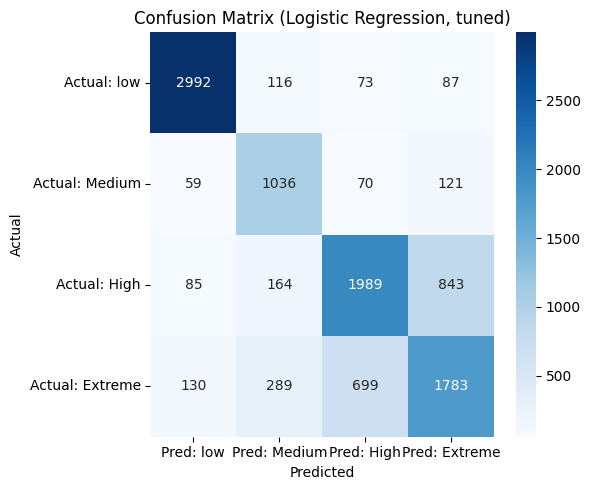

In [22]:
# confusion matrix
logger.info("Generating confusion matrix on test set")
labels_order = ["low", "Medium", "High", "Extreme"]
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual: {l}" for l in labels_order],
    columns=[f"Pred: {l}" for l in labels_order],
)
print("\nConfusion Matrix:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression, tuned)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


### Feature influence

Logistic Regression doesn't have `feature_importances_` like a tree model, but for a multiclass model we get one coefficient vector per class. The magnitude of each coefficient tells us how strongly that feature pushes the prediction toward (or away from) a given stress level. We look at the overall (mean absolute) influence per feature, and again roll it up by feature group (embedding dims vs emotion probabilities).

In [23]:
feature_names = embedding_cols + list(emotion_df.columns)

# model.coef_ has shape (n_classes, n_features) for multiclass logistic regression
coef_df = pd.DataFrame(model.coef_, columns=feature_names, index=model.classes_)
mean_abs_influence = coef_df.abs().mean(axis=0).sort_values(ascending=False)

print("Top 15 most influential features (mean |coefficient| across classes):")
print(mean_abs_influence.head(15))

# Aggregate influence by feature group (embedding vs emotion) for a clearer picture
group_influence = pd.Series({
    "BERT sentence embedding (sum)": mean_abs_influence[embedding_cols].sum(),
    "BERT emotion probabilities (sum)": mean_abs_influence[list(emotion_df.columns)].sum(),
})
print("\nInfluence by feature group:")
print(group_influence)


Top 15 most influential features (mean |coefficient| across classes):
embed_551    0.826154
embed_731    0.384861
embed_453    0.349247
embed_715    0.312309
embed_674    0.298019
embed_41     0.289085
embed_642    0.282677
embed_40     0.273826
embed_764    0.267635
embed_749    0.259315
embed_238    0.256890
embed_157    0.252899
embed_594    0.247588
embed_601    0.241486
embed_496    0.240511
dtype: float64

Influence by feature group:
BERT sentence embedding (sum)       78.304741
BERT emotion probabilities (sum)     0.379783
dtype: float64


## 8. Save artifacts

We save the trained classifier, the scaler, and the name of the single BERT model used, so the exact same feature pipeline (emotion probabilities + mean-pooled embedding from that one model) can be reproduced at inference time. There is no TF-IDF vectorizer and no second embedding model to save.

In [24]:
joblib.dump(model, "stress_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump({"bert_model": BERT_MODEL_NAME}, "bert_model_name.pkl")

print("Model, scaler and BERT model reference saved successfully!")


Model, scaler and BERT model reference saved successfully!
